# Customer Segmentation using K-Means Clustering
## Mall Customers Dataset 

**Objective:** Group mall customers into distinct segments based on their purchasing behavior (Annual Income and Spending Score), so the store can design targeted marketing strategies for each segment.

This notebook is organized into **numbered topics/sections**, each with a short explanation followed by the code that implements it, so every step is easy to follow and understand.


## 1. Business Problem Statement

A mall wants to understand its customers better. Instead of treating every customer the same way, the marketing team wants to divide customers into groups (segments) that share similar spending behavior. This is an **unsupervised learning problem** — there are no predefined labels, so we will use **K-Means Clustering** to discover natural groupings in the data.


## 2. Dataset Description

The dataset `Mall_Customers.csv` contains basic information collected by the mall through membership cards:

| Column | Description |
|---|---|
| CustomerID | Unique ID assigned to each customer |
| Gender | Male / Female |
| Age | Age of the customer |
| Annual Income (k$) | Customer's yearly income, in thousands of dollars |
| Spending Score (1-100) | A score assigned by the mall based on customer spending behavior |


## 3. Import Required Libraries

We start by importing all the libraries needed for data handling, visualization, and machine learning.

- `pandas`, `numpy` — data loading and numerical operations
- `matplotlib`, `seaborn` — data visualization
- `sklearn.preprocessing.StandardScaler` — feature scaling
- `sklearn.cluster.KMeans`, `AgglomerativeClustering`, `DBSCAN` — clustering algorithms
- `sklearn.decomposition.PCA` — dimensionality reduction for visualization
- `sklearn.metrics` — evaluation metrics for clustering
- `scipy.cluster.hierarchy` — dendrograms for hierarchical clustering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
%matplotlib inline


## 4. Load the Dataset

We load the CSV file into a pandas DataFrame.


In [4]:
df = pd.read_csv("Mall_Customers.csv")
df



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## 5. View the First Few Rows

A quick look at the top rows helps confirm the data loaded correctly.

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 6. View the Last Few Rows

In [6]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


## 7. Dataset Shape

Check how many rows (customers) and columns (features) are present.

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 200
Number of columns: 5


## 8. Column Names

In [8]:
df.columns.tolist()

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

## 9. Data Types of Each Column

In [9]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

## 10. Dataset Info Summary

`.info()` gives a combined view of column names, non-null counts, and data types.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## 11. Statistical Summary of Numerical Columns

In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 12. Statistical Summary Including Categorical Columns

In [12]:
df.describe(include='all')

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


## 13. Check for Missing Values

Missing values, if present, must be handled before clustering.

In [13]:
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0


## 14. Check for Duplicate Rows

In [14]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


## 15. Unique Value Counts per Column

In [15]:
df.nunique()

CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64

## 16. Check Unique Categories in 'Gender'

In [16]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

## 17. Rename Columns for Convenience

The original column names have spaces and special characters, which can make code harder to write. We'll create simpler aliases while keeping the original columns intact.

In [17]:
df = df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
})
df.head()


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 18. Encode Gender as a Numeric Column

Most ML algorithms require numeric input. We map `Male -> 0` and `Female -> 1` and store it in a new column, keeping the original `Gender` column for readability in plots.

In [18]:
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})
df.head()


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Gender_Encoded
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


## 19. Gender Distribution — Count Plot

C:\Users\HP\AppData\Local\Temp\ipykernel_24628\2866071691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='pastel')


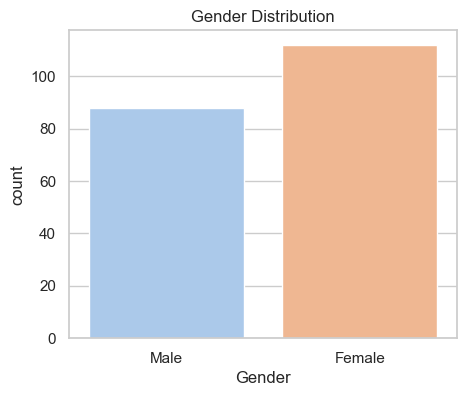

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Gender', palette='pastel')
plt.title('Gender Distribution')
plt.show()


## 20. Gender Distribution — Pie Chart

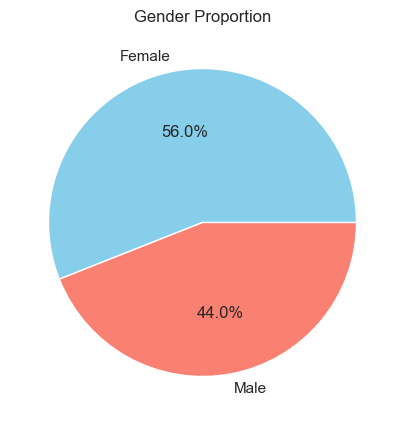

In [20]:
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['skyblue','salmon'])
plt.title('Gender Proportion')
plt.show()


## 21. Age Distribution — Histogram

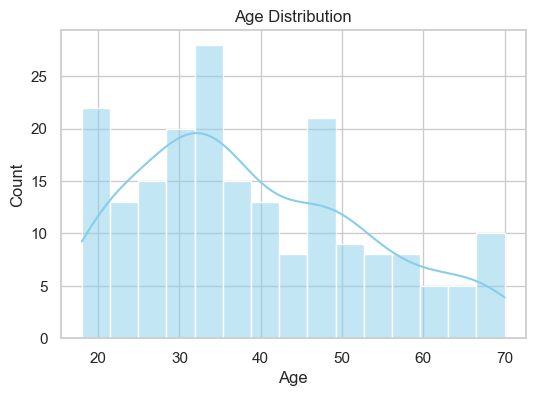

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()


## 22. Age Distribution — Boxplot (Outlier Check)

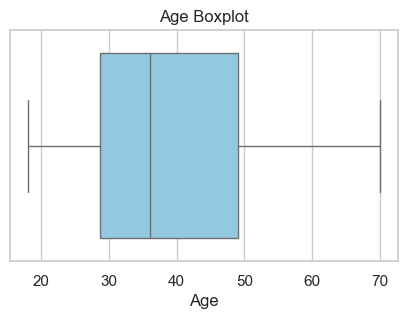

In [22]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df['Age'], color='skyblue')
plt.title('Age Boxplot')
plt.show()


## 
23. Annual Income Distribution — Histogram

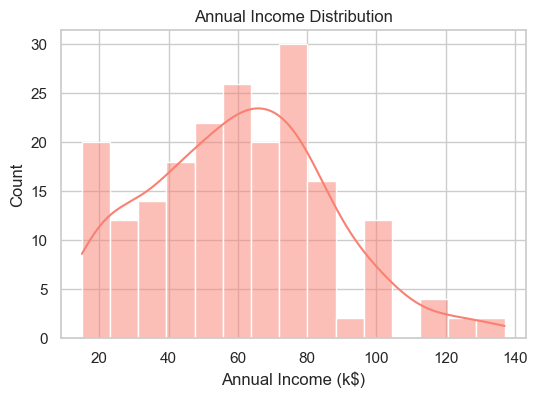

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual_Income'], bins=15, kde=True, color='salmon')
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.show()


## 24. Annual Income Distribution — Boxplot

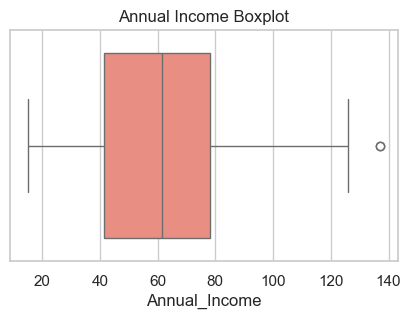

In [24]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df['Annual_Income'], color='salmon')
plt.title('Annual Income Boxplot')
plt.show()


## 25. Spending Score Distribution — Histogram

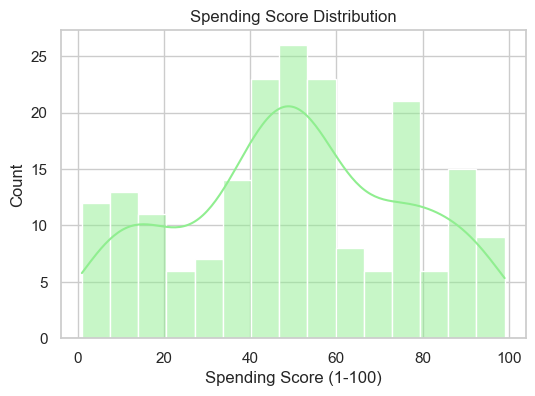

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(df['Spending_Score'], bins=15, kde=True, color='lightgreen')
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score (1-100)')
plt.show()


## 26. Spending Score Distribution — Boxplot

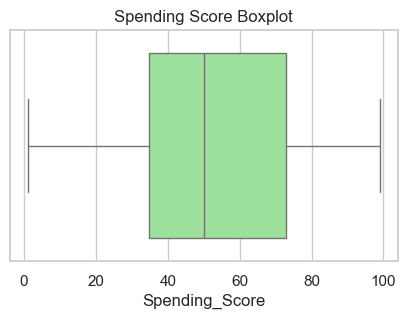

In [26]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df['Spending_Score'], color='lightgreen')
plt.title('Spending Score Boxplot')
plt.show()


## 27. Correlation Heatmap

This shows how strongly the numerical features are related to each other.

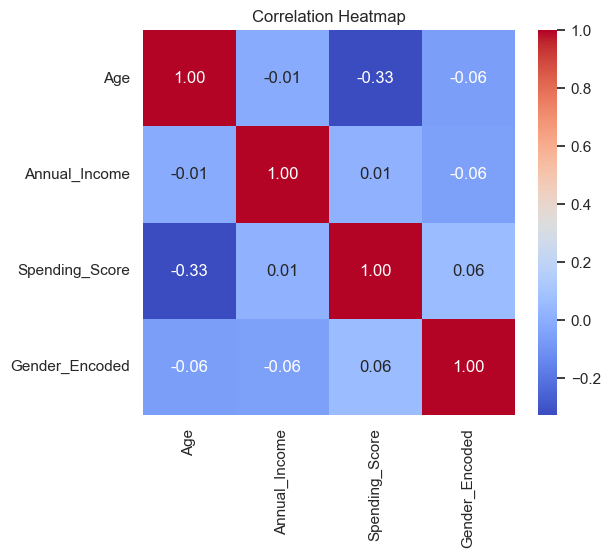

In [27]:
plt.figure(figsize=(6,5))
corr = df[['Age','Annual_Income','Spending_Score','Gender_Encoded']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


## 28. Pairplot of Numerical Features

A pairplot lets us see the relationship between every pair of numerical features at once, colored by Gender.

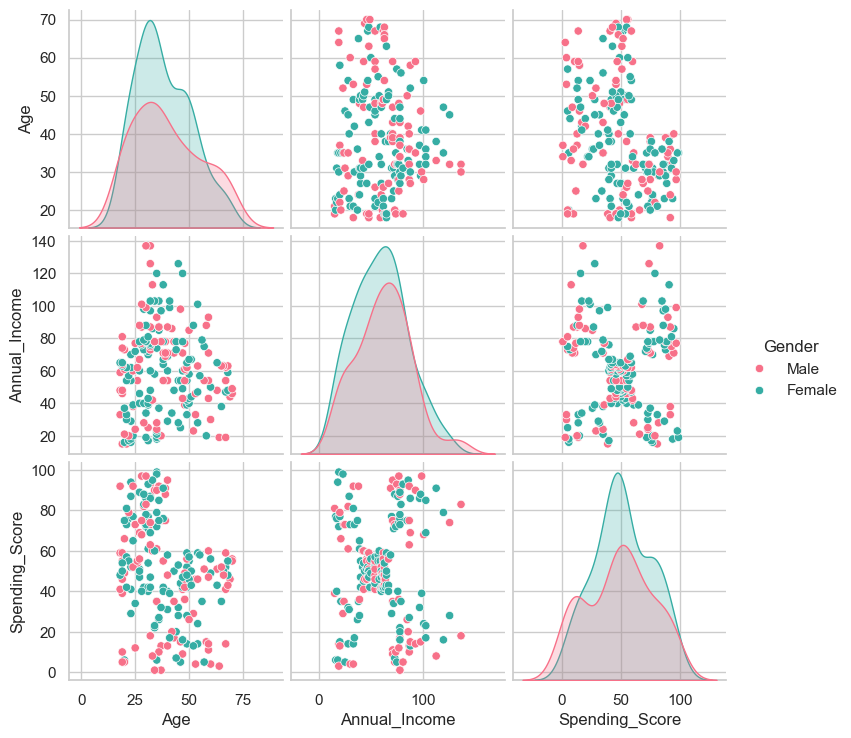

In [28]:
sns.pairplot(df, vars=['Age','Annual_Income','Spending_Score'], hue='Gender', palette='husl')
plt.show()


## 29. Age vs Annual Income

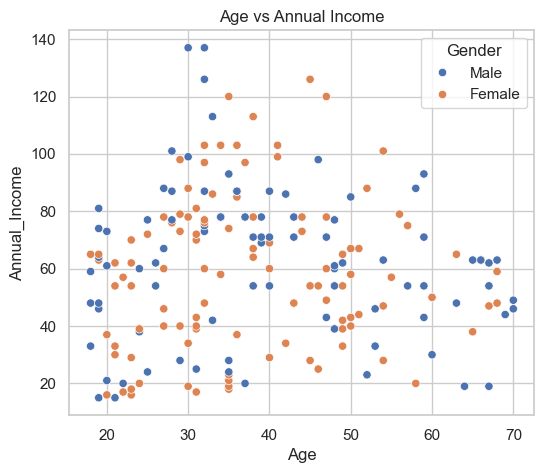

In [30]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Age', y='Annual_Income', hue='Gender')
plt.title('Age vs Annual Income')
plt.show()


## 30. Age vs Spending Score

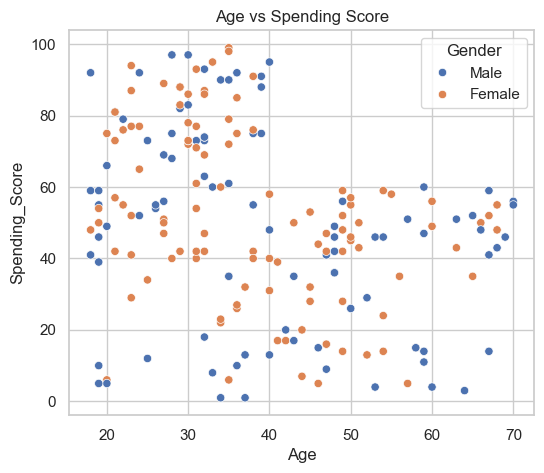

In [31]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Age', y='Spending_Score', hue='Gender')
plt.title('Age vs Spending Score')
plt.show()


## 31. Annual Income vs Spending Score

This is the most important scatter plot for our clustering problem — the pattern here is what K-Means will try to capture.

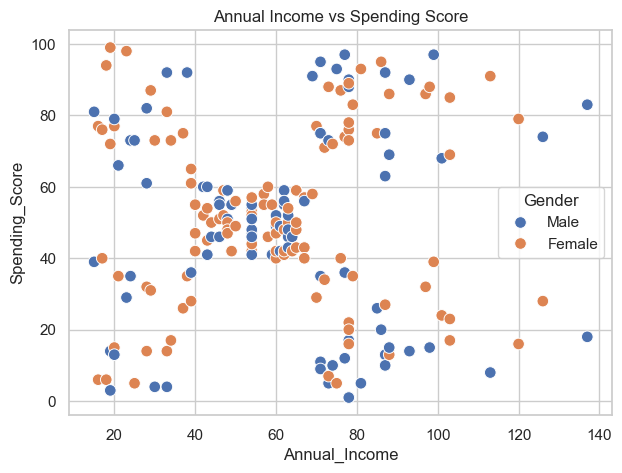

In [32]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Gender', s=70)
plt.title('Annual Income vs Spending Score')
plt.show()


## 32. Gender-wise Average Annual Income and Spending Score

In [33]:
df.groupby('Gender')[['Age','Annual_Income','Spending_Score']].mean()

,Age,Annual_Income,Spending_Score
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


## 33. Age Group Segmentation (Binning)

To understand spending patterns by age bracket, we bin customers into age groups.

C:\Users\HP\AppData\Local\Temp\ipykernel_24628\3194380275.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Age_Group', y='Spending_Score', estimator=np.mean, palette='viridis')


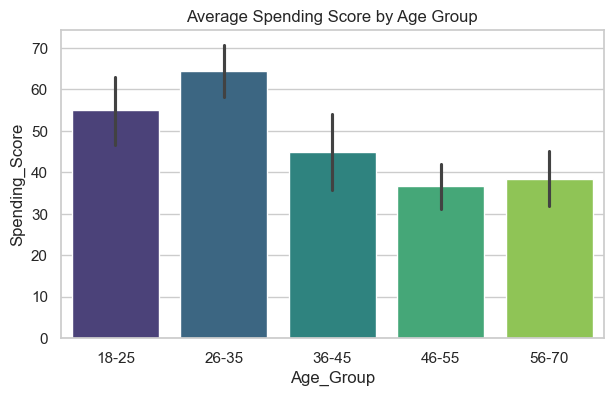

In [34]:
bins = [17, 25, 35, 45, 55, 70]
labels = ['18-25','26-35','36-45','46-55','56-70']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.figure(figsize=(7,4))
sns.barplot(data=df, x='Age_Group', y='Spending_Score', estimator=np.mean, palette='viridis')
plt.title('Average Spending Score by Age Group')
plt.show()


## 34. Outlier Detection Summary (IQR Method)

We use the Interquartile Range (IQR) method to flag potential outliers in the numerical columns.

In [35]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

for col in ['Age','Annual_Income','Spending_Score']:
    print(f"Outliers in {col}: {count_outliers_iqr(df[col])}")


Outliers in Age: 0
Outliers in Annual_Income: 2
Outliers in Spending_Score: 0


## 35. Feature Selection for Clustering

For the core segmentation task, we use **Annual Income** and **Spending Score**, since these two features best capture purchasing behavior and produce clear, business-interpretable segments.

In [36]:
X = df[['Annual_Income', 'Spending_Score']]
X.head()


,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 36. Feature Scaling

K-Means relies on distance calculations, so features should be on a similar scale. We use `StandardScaler` to transform the data to have mean = 0 and standard deviation = 1.

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature sample:")
print(X_scaled[:5])


Scaled feature sample:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## 37. Finding Optimal K — Elbow Method

We run K-Means for k = 1 to 10 and record the **Within-Cluster Sum of Squares (WCSS / inertia)** for each. The point where the curve starts to flatten (the 'elbow') suggests the optimal number of clusters.

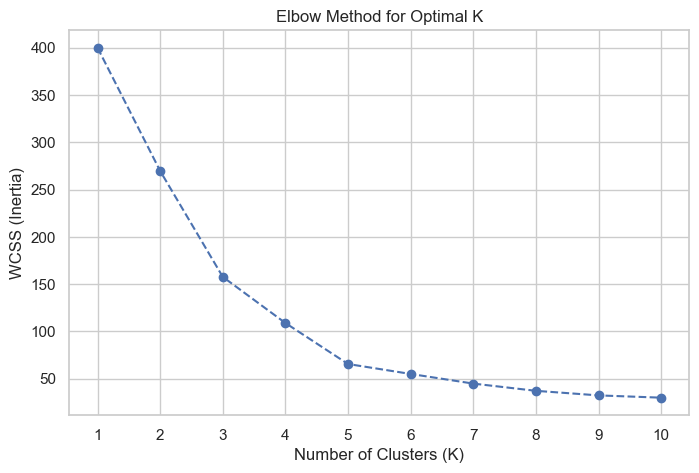

In [38]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.show()


## 38. Finding Optimal K — Silhouette Score Method

The **silhouette score** measures how well-separated the clusters are (ranges from -1 to 1; higher is better). We compute it for several values of k as a second, independent check on our choice of K.

In [39]:
silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")


K = 2, Silhouette Score = 0.3213
K = 3, Silhouette Score = 0.4666
K = 4, Silhouette Score = 0.4939
K = 5, Silhouette Score = 0.5547
K = 6, Silhouette Score = 0.5399
K = 7, Silhouette Score = 0.5281
K = 8, Silhouette Score = 0.4552
K = 9, Silhouette Score = 0.4571
K = 10, Silhouette Score = 0.4432


## 39. Silhouette Score Visualization

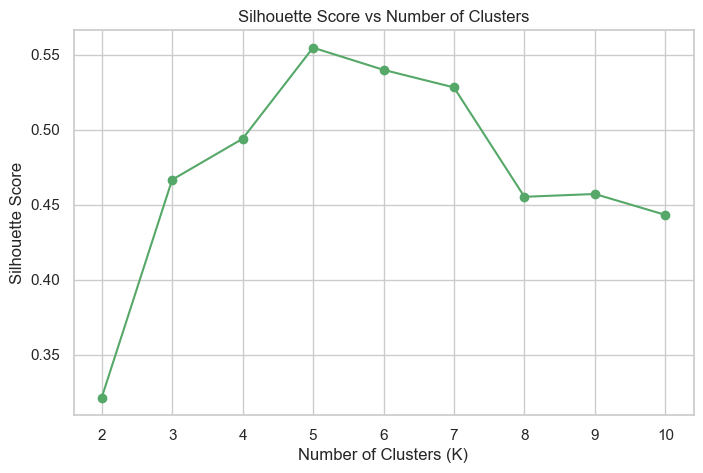

In [40]:
plt.figure(figsize=(8,5))
plt.plot(list(K_range_sil), silhouette_scores, marker='o', color='g')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(K_range_sil))
plt.show()


**Conclusion from Elbow + Silhouette analysis:** Both methods point to **K = 5** as the optimal number of clusters — the elbow curve flattens around k = 5, and the silhouette score peaks (or is near its peak) at the same value.


## 40. Train the Final K-Means Model

We now train the final K-Means model using the chosen value, K = 5.

In [41]:
K_OPTIMAL = 5

kmeans = KMeans(n_clusters=K_OPTIMAL, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print("Model trained. Cluster centers (scaled space):")
print(kmeans.cluster_centers_)


Model trained. Cluster centers (scaled space):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


## 41. Assign Cluster Labels Back to the Dataset

In [42]:
df['Cluster'] = cluster_labels
df.head(10)


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Gender_Encoded,Age_Group,Cluster
0,1,Male,19,15,39,0,18-25,4
1,2,Male,21,15,81,0,18-25,2
2,3,Female,20,16,6,1,18-25,4
3,4,Female,23,16,77,1,18-25,2
4,5,Female,31,17,40,1,26-35,4
5,6,Female,22,17,76,1,18-25,2
6,7,Female,35,18,6,1,26-35,4
7,8,Female,23,18,94,1,18-25,2
8,9,Male,64,19,3,0,56-70,4
9,10,Female,30,19,72,1,26-35,2


## 42. Count of Customers in Each Cluster

C:\Users\HP\AppData\Local\Temp\ipykernel_24628\20085020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cluster', palette='Set2')


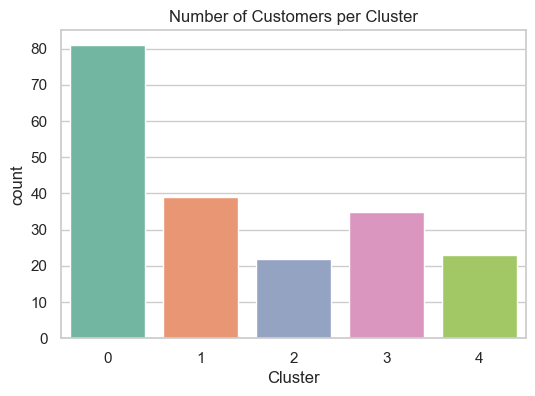

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Cluster', palette='Set2')
plt.title('Number of Customers per Cluster')
plt.show()


## 43. Visualize Clusters — 2D Scatter Plot with Centroids

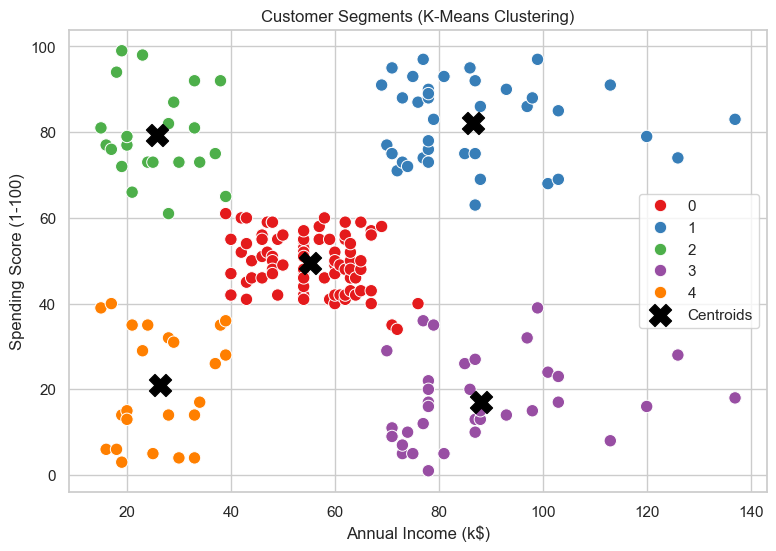

In [44]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df, x='Annual_Income', y='Spending_Score',
    hue='Cluster', palette='Set1', s=80
)

# Convert centroids back to the original (unscaled) space for plotting
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_original[:,0], centers_original[:,1],
            s=250, c='black', marker='X', label='Centroids')

plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


## 44. 3D Clustering Visualization (Age, Income, Spending Score)

To see how clusters look when Age is also considered, we visualize the same customers in 3D space.

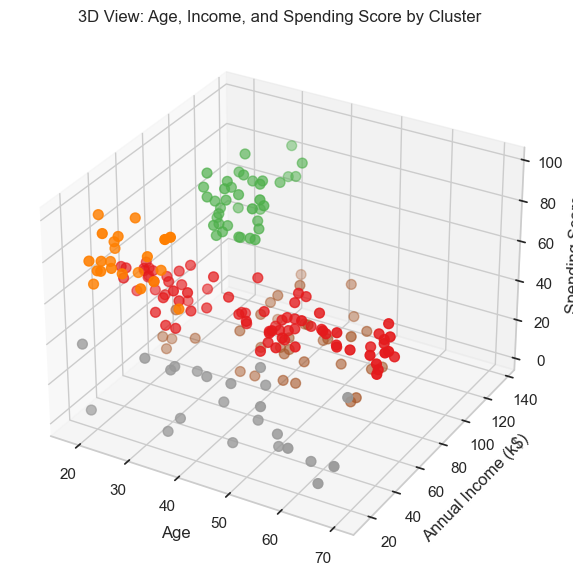

In [45]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['Age'], df['Annual_Income'], df['Spending_Score'],
                      c=df['Cluster'], cmap='Set1', s=50)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score')
ax.set_title('3D View: Age, Income, and Spending Score by Cluster')
plt.show()


## 45. Cluster-wise Statistical Summary

We compute the average Age, Annual Income, and Spending Score for each cluster, along with the number of customers in each — this is the foundation of customer profiling.

In [46]:
cluster_summary = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean().round(1)
cluster_summary['Customer_Count'] = df['Cluster'].value_counts().sort_index()
cluster_summary


,Age,Annual_Income,Spending_Score,Customer_Count
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


## 46. Cluster-wise Gender Distribution

In [47]:
pd.crosstab(df['Cluster'], df['Gender'])


Gender,Female,Male
Cluster,,
0,48,33
1,21,18
2,13,9
3,16,19
4,14,9


## 47. Boxplots of Each Feature Across Clusters

Boxplots make it easy to compare how each feature's distribution differs from one cluster to another.

C:\Users\HP\AppData\Local\Temp\ipykernel_24628\2240308078.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y='Age', ax=axes[0], palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_24628\2240308078.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y='Annual_Income', ax=axes[1], palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_24628\2240308078.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y='Spending_Score', ax=axes[2], palette='Set2')


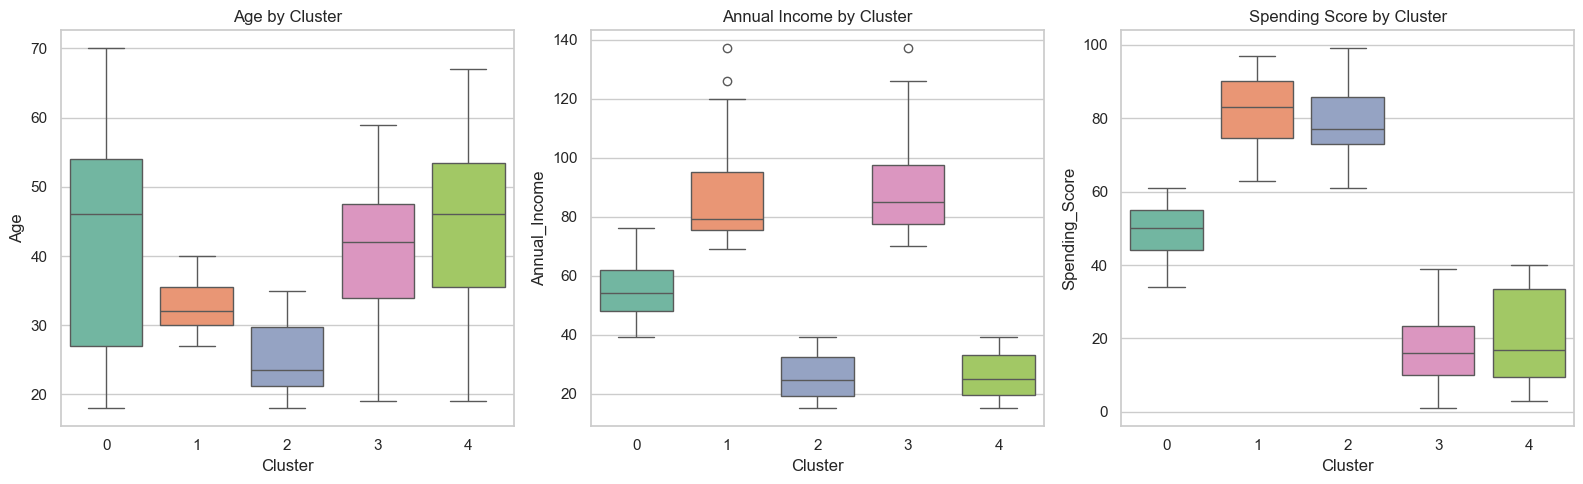

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.boxplot(data=df, x='Cluster', y='Age', ax=axes[0], palette='Set2')
axes[0].set_title('Age by Cluster')

sns.boxplot(data=df, x='Cluster', y='Annual_Income', ax=axes[1], palette='Set2')
axes[1].set_title('Annual Income by Cluster')

sns.boxplot(data=df, x='Cluster', y='Spending_Score', ax=axes[2], palette='Set2')
axes[2].set_title('Spending Score by Cluster')

plt.tight_layout()
plt.show()


## 48. Cluster Profiling — Naming the Segments

Based on the statistics above, we assign a business-friendly name to each cluster. (Cluster numbers can vary between runs — always cross-check with the summary table in Topic 45 before finalizing labels.)

In [49]:
cluster_names = {
    0: 'Average Customers (Medium Income, Medium Spending)',
    1: 'Careful Spenders (High Income, Low Spending)',
    2: 'Budget Customers (Low Income, Low Spending)',
    3: 'Impulsive Spenders (Low Income, High Spending)',
    4: 'Target Customers (High Income, High Spending)'
}

df['Segment_Name'] = df['Cluster'].map(cluster_names)
df[['CustomerID','Annual_Income','Spending_Score','Cluster','Segment_Name']].head(10)


,CustomerID,Annual_Income,Spending_Score,Cluster,Segment_Name
0,1,15,39,4,"Target Customers (High Income, High Spending)"
1,2,15,81,2,"Budget Customers (Low Income, Low Spending)"
2,3,16,6,4,"Target Customers (High Income, High Spending)"
3,4,16,77,2,"Budget Customers (Low Income, Low Spending)"
4,5,17,40,4,"Target Customers (High Income, High Spending)"
5,6,17,76,2,"Budget Customers (Low Income, Low Spending)"
6,7,18,6,4,"Target Customers (High Income, High Spending)"
7,8,18,94,2,"Budget Customers (Low Income, Low Spending)"
8,9,19,3,4,"Target Customers (High Income, High Spending)"
9,10,19,72,2,"Budget Customers (Low Income, Low Spending)"


## 49. Comparison with Hierarchical Clustering (Dendrogram)

As a sanity check, we compare K-Means with **Agglomerative (Hierarchical) Clustering**. A dendrogram helps visually confirm how many natural clusters exist in the data.

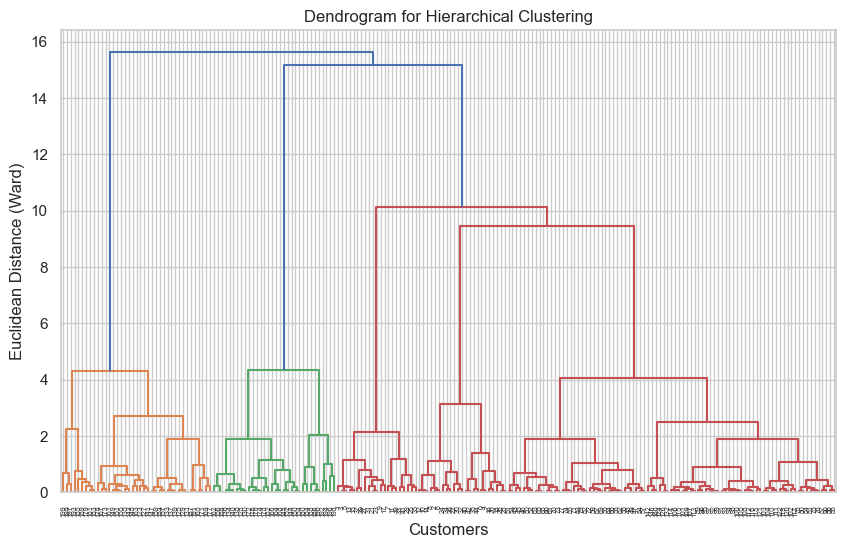

In [50]:
plt.figure(figsize=(10,6))
merged_links = linkage(X_scaled, method='ward')
dendrogram(merged_links)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance (Ward)')
plt.show()


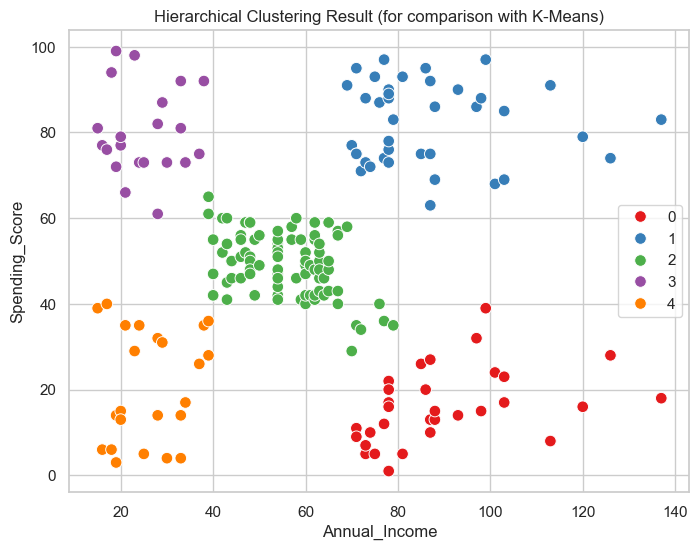

In [51]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue=hc_labels, palette='Set1', s=70)
plt.title('Hierarchical Clustering Result (for comparison with K-Means)')
plt.show()


## 50. Comparison with DBSCAN Clustering

**DBSCAN** groups points based on density and can automatically detect noise/outliers, unlike K-Means which forces every point into a cluster. This gives us another perspective on the data's structure.

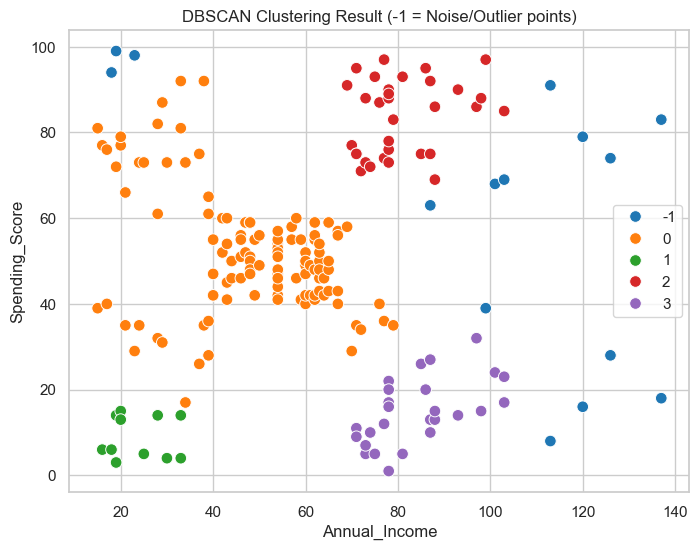

Number of clusters found by DBSCAN (excluding noise): 4
Number of noise points: 15


In [52]:
dbscan = DBSCAN(eps=0.4, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue=dbscan_labels, palette='tab10', s=70)
plt.title('DBSCAN Clustering Result (-1 = Noise/Outlier points)')
plt.show()

print("Number of clusters found by DBSCAN (excluding noise):",
      len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Number of noise points:", list(dbscan_labels).count(-1))


## 51. Dimensionality Reduction with PCA

To see how customers would cluster if we included **all** numerical features (Age, Income, Spending Score, Gender), we first reduce them to 2 principal components using PCA, then visualize the result.

Explained variance ratio by each principal component: [0.33690046 0.26230645]


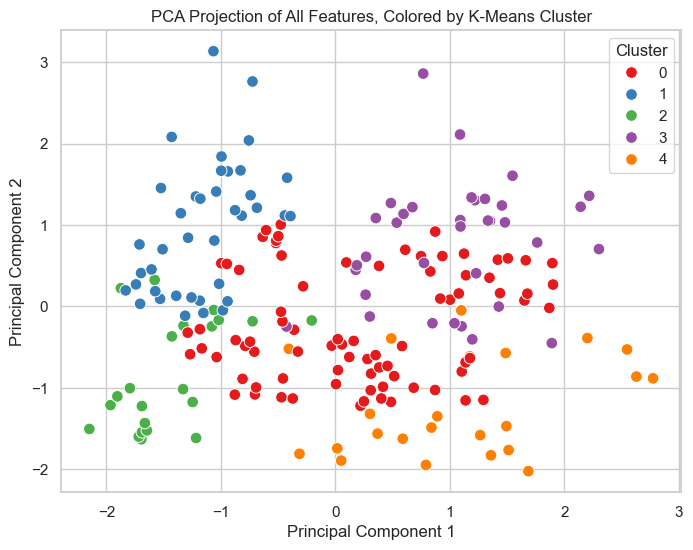

In [53]:
features_all = df[['Age','Annual_Income','Spending_Score','Gender_Encoded']]
features_scaled_all = StandardScaler().fit_transform(features_all)

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(features_scaled_all)

print("Explained variance ratio by each principal component:", pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=df['Cluster'], palette='Set1', s=70)
plt.title('PCA Projection of All Features, Colored by K-Means Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


## 52. Model Evaluation Metrics

We evaluate our final K-Means model (K=5) using multiple standard clustering metrics:

- **Inertia (WCSS):** lower is better — measures compactness of clusters
- **Silhouette Score:** ranges -1 to 1, higher is better — measures separation between clusters
- **Davies-Bouldin Index:** lower is better — measures average similarity between each cluster and its most similar one

In [54]:
inertia_final = kmeans.inertia_
silhouette_final = silhouette_score(X_scaled, cluster_labels)
db_index_final = davies_bouldin_score(X_scaled, cluster_labels)

print(f"Inertia (WCSS): {inertia_final:.2f}")
print(f"Silhouette Score: {silhouette_final:.4f}")
print(f"Davies-Bouldin Index: {db_index_final:.4f}")


Inertia (WCSS): 65.57
Silhouette Score: 0.5547
Davies-Bouldin Index: 0.5722


## 53. Silhouette Plot per Cluster

This plot shows the silhouette coefficient of every individual customer, grouped by cluster — a useful diagnostic to check if any cluster is poorly separated.

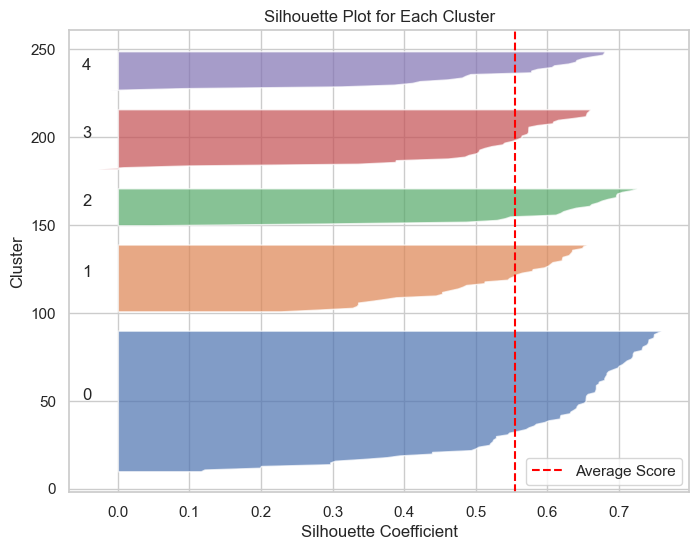

In [55]:
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

fig, ax = plt.subplots(figsize=(8,6))
y_lower = 10

for i in range(K_OPTIMAL):
    ith_values = sample_silhouette_values[cluster_labels == i]
    ith_values.sort()
    size_i = ith_values.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_final, color="red", linestyle="--", label='Average Score')
ax.set_title('Silhouette Plot for Each Cluster')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.show()


## 54. Save the Final Clustered Dataset

We export the dataset (with cluster labels and segment names) to a new CSV file, so it can be shared with the marketing team or used in a dashboard.

In [56]:
df.to_csv('Mall_Customers_Clustered.csv', index=False)
print("Clustered dataset saved as 'Mall_Customers_Clustered.csv'")


Clustered dataset saved as 'Mall_Customers_Clustered.csv'


## 55. Business Insights & Recommendations

Based on the cluster profiles built in this notebook, here are the actionable insights:

- **Target Customers (High Income, High Spending):** The most valuable segment. Focus premium product launches, loyalty programs, and personalized offers here.
- **Careful Spenders (High Income, Low Spending):** Have the purchasing power but aren't spending much. Target with engagement campaigns, exclusive previews, or incentives to convert potential into actual spending.
- **Impulsive Spenders (Low Income, High Spending):** Spend despite lower income — respond well to discounts, flash sales, and installment/EMI options.
- **Budget Customers (Low Income, Low Spending):** Price-sensitive segment. Best reached with value bundles, discounts, and essential product promotions.
- **Average Customers (Medium Income, Medium Spending):** The largest, most "typical" group — general marketing campaigns and seasonal offers work well here.


## 56. Conclusion

- We performed a complete customer segmentation analysis on the Mall Customers dataset using **K-Means Clustering**.
- Both the **Elbow Method** and **Silhouette Score** confirmed that **K = 5** is the optimal number of clusters.
- We validated our results by comparing them with **Hierarchical Clustering** and **DBSCAN**, and by reducing the feature space with **PCA**.
- The resulting 5 customer segments are clearly interpretable and directly usable by the marketing team for targeted campaigns.
